In [1]:
#import required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, mannwhitneyu, shapiro, pearsonr
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, classification_report, confusion_matrix
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Aesthetics 
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# EPL colour palette
EPL_PURPLE   = '#37003C'
EPL_GREEN    = '#00FF85'
EPL_BLUE     = '#04F5FF'
PALETTE_HOME = '#3A86FF'
PALETTE_AWAY = '#FF006E'
PALETTE_DRAW = '#8338EC'

In [3]:
#Reading the data in
df = pd.read_csv('epl_final.csv')
#Check the number of rows and columns
df.shape

(9380, 22)

In [4]:
#Check for missing data 
# ── Missing values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values found in the dataset.')
else:
    print('⚠️  Missing values detected:')
    display(missing_df)

✅ No missing values found in the dataset.


In [5]:
#Check data type 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Season             9380 non-null   str  
 1   MatchDate          9380 non-null   str  
 2   HomeTeam           9380 non-null   str  
 3   AwayTeam           9380 non-null   str  
 4   FullTimeHomeGoals  9380 non-null   int64
 5   FullTimeAwayGoals  9380 non-null   int64
 6   FullTimeResult     9380 non-null   str  
 7   HalfTimeHomeGoals  9380 non-null   int64
 8   HalfTimeAwayGoals  9380 non-null   int64
 9   HalfTimeResult     9380 non-null   str  
 10  HomeShots          9380 non-null   int64
 11  AwayShots          9380 non-null   int64
 12  HomeShotsOnTarget  9380 non-null   int64
 13  AwayShotsOnTarget  9380 non-null   int64
 14  HomeCorners        9380 non-null   int64
 15  AwayCorners        9380 non-null   int64
 16  HomeFouls          9380 non-null   int64
 17  AwayFouls          9380 n

In [6]:
season_games_count = df.groupby('Season')['MatchDate'].size().reset_index()
incomplete_seasons = []
for _,row in season_games_count.iterrows():
    
    if row['MatchDate'] < 380:
        incomplete_seasons.append(row['Season'])

print('The seasons listed have imcomplete games in the dataset:')
incomplete_seasons


The seasons listed have imcomplete games in the dataset:


['2003/04', '2004/05', '2024/25']

In [7]:
#Convert the MatchDate column to date 
df['MatchDate'] = pd.to_datetime(df['MatchDate'])

In [8]:
#Dropping the seasons with incomplete matches 
df_cleaned = df[~df['Season'].isin(incomplete_seasons)]

In [9]:
df_cleaned['Season'].value_counts()

Season
2000/01    380
2001/02    380
2002/03    380
2005/06    380
2006/07    380
2007/08    380
2008/09    380
2009/10    380
2010/11    380
2011/12    380
2012/13    380
2013/14    380
2014/15    380
2015/16    380
2016/17    380
2017/18    380
2018/19    380
2019/20    380
2020/21    380
2021/22    380
2022/23    380
2023/24    380
Name: count, dtype: int64

In [10]:


# Convert the columns Season, HomeTeam,AwayTeam,FullTimeResult,HalfTimeResult
df_cleaned[['Season','HomeTeam','AwayTeam','FullTimeResult','HalfTimeResult']] = \
df_cleaned[['Season','HomeTeam','AwayTeam','FullTimeResult','HalfTimeResult']] .astype('category')
df_cleaned.info()


<class 'pandas.DataFrame'>
Index: 8360 entries, 0 to 9029
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Season             8360 non-null   category      
 1   MatchDate          8360 non-null   datetime64[us]
 2   HomeTeam           8360 non-null   category      
 3   AwayTeam           8360 non-null   category      
 4   FullTimeHomeGoals  8360 non-null   int64         
 5   FullTimeAwayGoals  8360 non-null   int64         
 6   FullTimeResult     8360 non-null   category      
 7   HalfTimeHomeGoals  8360 non-null   int64         
 8   HalfTimeAwayGoals  8360 non-null   int64         
 9   HalfTimeResult     8360 non-null   category      
 10  HomeShots          8360 non-null   int64         
 11  AwayShots          8360 non-null   int64         
 12  HomeShotsOnTarget  8360 non-null   int64         
 13  AwayShotsOnTarget  8360 non-null   int64         
 14  HomeCorners        8360 

In [11]:
#  Overall home advantage metrics
total_matches = len(df)
home_wins  = (df['FullTimeResult'] == 'H').sum()
away_wins  = (df['FullTimeResult'] == 'A').sum()
draws      = (df['FullTimeResult'] == 'D').sum()

avg_home_goals = df['FullTimeHomeGoals'].mean()
avg_away_goals = df['FullTimeAwayGoals'].mean()
avg_home_shots = df['HomeShots'].mean()
avg_away_shots = df['AwayShots'].mean()

print('='*55)
print('       HOME ADVANTAGE — SUMMARY STATISTICS')
print('='*55)
print(f'  Total Matches Analysed : {total_matches:,}')
print(f'  Home Win Rate          : {home_wins/total_matches*100:.1f}%  ({home_wins:,} wins)')
print(f'  Away Win Rate          : {away_wins/total_matches*100:.1f}%  ({away_wins:,} wins)')
print(f'  Draw Rate              : {draws/total_matches*100:.1f}%  ({draws:,} draws)')
print('-'*55)
print(f'  Avg Home Goals         : {avg_home_goals:.3f}')
print(f'  Avg Away Goals         : {avg_away_goals:.3f}')
print(f'  Home Goal Advantage    : +{avg_home_goals - avg_away_goals:.3f} goals/game')
print('-'*55)
print(f'  Avg Home Shots         : {avg_home_shots:.2f}')
print(f'  Avg Away Shots         : {avg_away_shots:.2f}')
print('='*55)

       HOME ADVANTAGE — SUMMARY STATISTICS
  Total Matches Analysed : 9,380
  Home Win Rate          : 45.8%  (4,299 wins)
  Away Win Rate          : 29.5%  (2,768 wins)
  Draw Rate              : 24.7%  (2,313 draws)
-------------------------------------------------------
  Avg Home Goals         : 1.535
  Avg Away Goals         : 1.183
  Home Goal Advantage    : +0.353 goals/game
-------------------------------------------------------
  Avg Home Shots         : 13.62
  Avg Away Shots         : 10.81


C:\Users\DELL\AppData\Local\Temp\ipykernel_17084\3196807570.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(season_ha['Season'], rotation=45, ha='right')


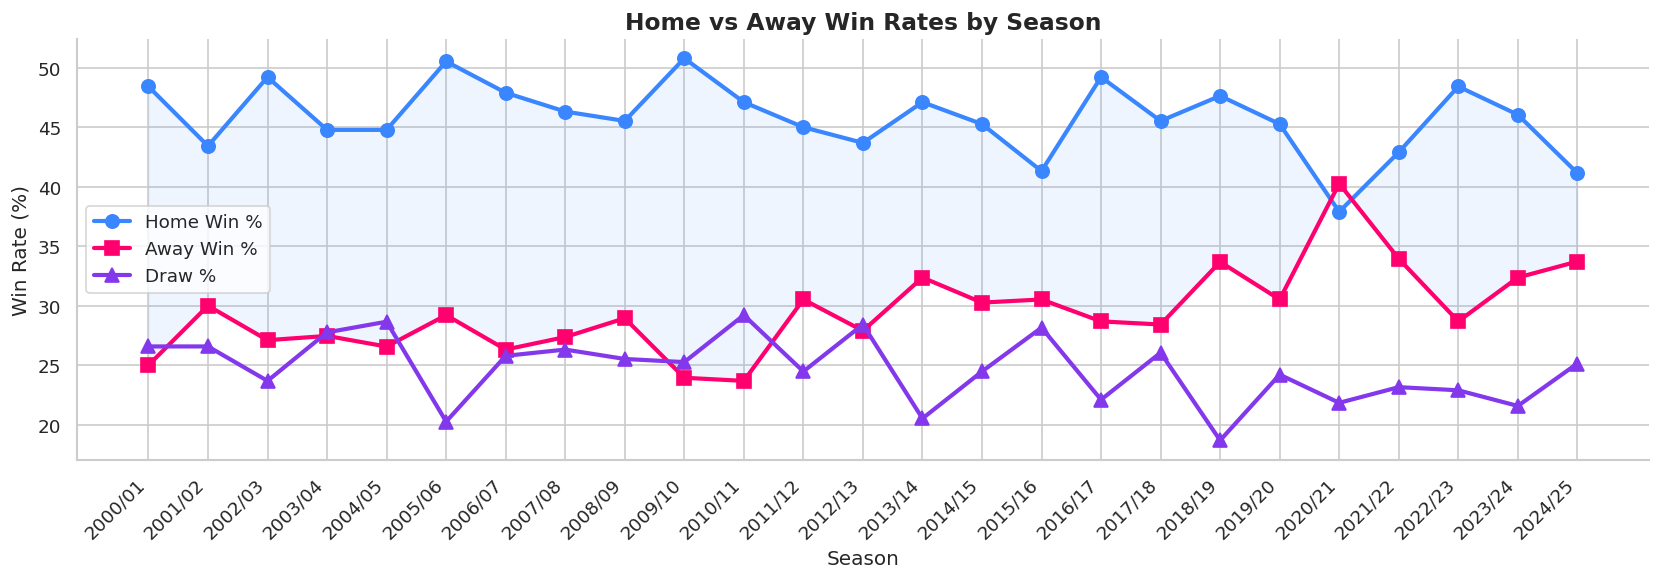

In [12]:
#  Home advantage by season 
season_ha = df.groupby('Season').apply(lambda x: pd.Series({
    'HomeWinRate' : (x['FullTimeResult'] == 'H').mean() * 100,
    'AwayWinRate' : (x['FullTimeResult'] == 'A').mean() * 100,
    'DrawRate'    : (x['FullTimeResult'] == 'D').mean() * 100,
})).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(season_ha['Season'], season_ha['HomeWinRate'], marker='o',
        color=PALETTE_HOME, linewidth=2.5, markersize=8, label='Home Win %')
ax.plot(season_ha['Season'], season_ha['AwayWinRate'], marker='s',
        color=PALETTE_AWAY, linewidth=2.5, markersize=8, label='Away Win %')
ax.plot(season_ha['Season'], season_ha['DrawRate'], marker='^',
        color=PALETTE_DRAW, linewidth=2.5, markersize=8, label='Draw %')

ax.fill_between(season_ha['Season'], season_ha['HomeWinRate'], season_ha['AwayWinRate'],
                alpha=0.08, color=PALETTE_HOME)

ax.set_title('Home vs Away Win Rates by Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Win Rate (%)')
ax.set_xlabel('Season')
ax.set_xticklabels(season_ha['Season'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
# plt.savefig('fig_04_home_advantage_season.png', bbox_inches='tight')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_17084\1124826234.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(season_ld['Month'], rotation=45, ha='right')


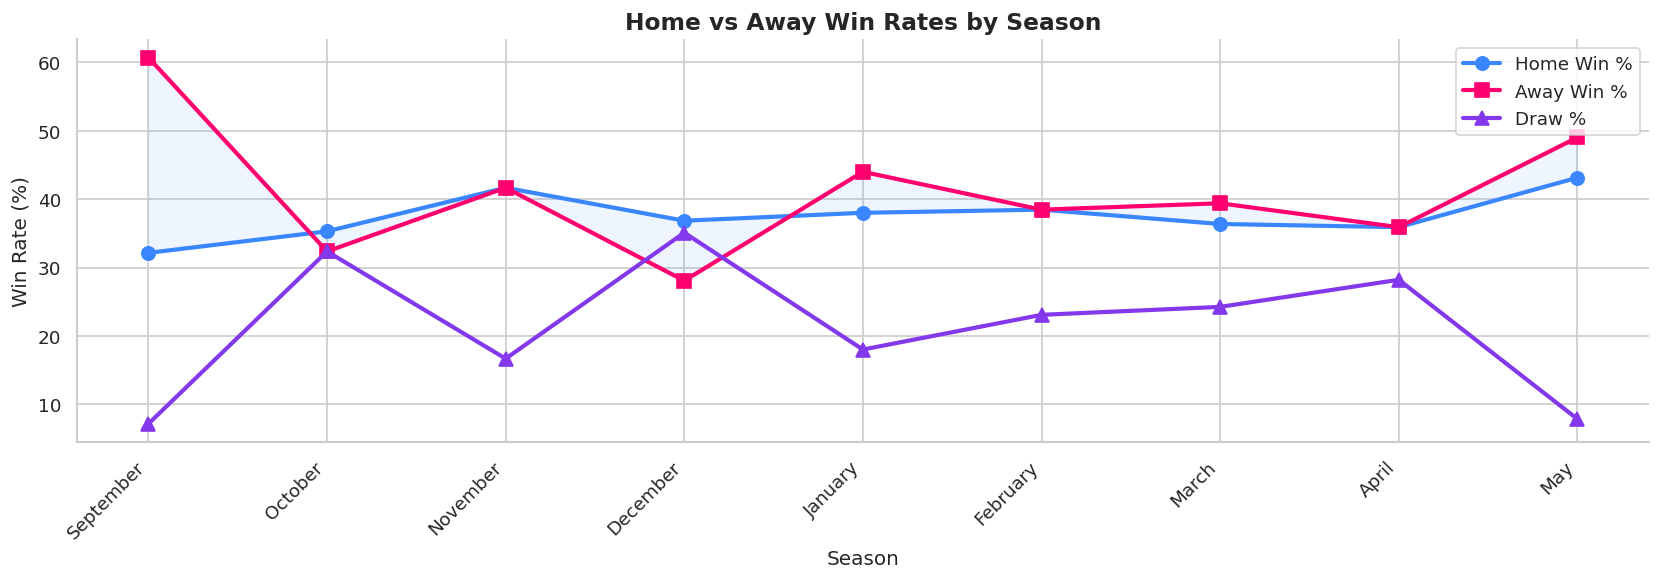

In [13]:
#Visualizing the lockdown fixtures 
lock_down = df[df['Season'] == '2020/21']
lock_down['Month'] = lock_down['MatchDate'].dt.month_name()
season_ld = lock_down.groupby('Month').apply(lambda x: pd.Series({
    'HomeWinRate' : (x['FullTimeResult'] == 'H').mean() * 100,
    'AwayWinRate' : (x['FullTimeResult'] == 'A').mean() * 100,
    'DrawRate'    : (x['FullTimeResult'] == 'D').mean() * 100,
}))


desired_order =  [ 'September',  'October','November','December', 'January', 'February', 'March','April', 'May']
season_ld = season_ld.reindex(index=desired_order)
season_ld = season_ld.reset_index()
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(season_ld['Month'], season_ld['HomeWinRate'], marker='o',
        color=PALETTE_HOME, linewidth=2.5, markersize=8, label='Home Win %')
ax.plot(season_ld['Month'], season_ld['AwayWinRate'], marker='s',
        color=PALETTE_AWAY, linewidth=2.5, markersize=8, label='Away Win %')
ax.plot(season_ld['Month'], season_ld['DrawRate'], marker='^',
        color=PALETTE_DRAW, linewidth=2.5, markersize=8, label='Draw %')

ax.fill_between(season_ld['Month'], season_ld['HomeWinRate'], season_ld['AwayWinRate'],
                alpha=0.08, color=PALETTE_HOME)

ax.set_title('Home vs Away Win Rates by Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Win Rate (%)')
ax.set_xlabel('Season')
ax.set_xticklabels(season_ld['Month'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
# plt.savefig('fig_04_home_advantage_season.png', bbox_inches='tight')
plt.show()



In [14]:
#Subjecting the data to a hpothesis testing
# Count outcomes
home_wins = df[df["FullTimeResult"] == "H"].shape[0]
draws     = df[df["FullTimeResult"] == "D"].shape[0]
away_wins = df[df["FullTimeResult"] == "A"].shape[0]


print("Home wins:", home_wins)
print("Draws:    ", draws)
print("Away wins:", away_wins)




# Total non‑draw games
n_non_draw = home_wins + away_wins

# Number of home wins (successes)
count_home_wins = home_wins

# Null hypothesis: home‑win probability = 0.5
p0 = 0.5

# Test
stat, p_value = proportions_ztest(
    count = count_home_wins,
    nobs  = n_non_draw,
    value = p0
)

alpha = 0.05
print("z‑statistic:", stat)
print("p‑value:    ", p_value)

if p_value < alpha and stat > 0:
    print("Reject H₀: Home teams win more than a toss‑up (home advantage exists).")
else:
    print("Fail to reject H₀: Home advantage looks like a toss‑up.")

Home wins: 4299
Draws:     2313
Away wins: 2768
z‑statistic: 18.655031007492298
p‑value:     1.1493549478872781e-77
Reject H₀: Home teams win more than a toss‑up (home advantage exists).


In [15]:
#Do away wins happen more often in the second half of the season than the first?

df_cleaned = df_cleaned.sort_values(["Season", "MatchDate"])  # sort by season then date

#Creating a pseudo-matchweek column
df_cleaned["matchweek"] = df_cleaned.groupby("Season").cumcount() + 1

# Defining first vs second half of season (EPL = 38 matchweeks)
df_cleaned["half_season"] = df_cleaned["matchweek"].apply(
    lambda x: "first" if x <= 18 else "second"
)

#  Mark away wins
df_cleaned["away_win"] = (df_cleaned["FullTimeResult"] == "A").astype(int)

# Split counts
df_first = df_cleaned[df_cleaned["half_season"] == "first"]
df_second = df_cleaned[df_cleaned["half_season"] == "second"]

n1 = df_first.shape[0]    # total games first half
n2 = df_second.shape[0]   # total games second half

x1 = df_first["away_win"].sum()  # away wins first half
x2 = df_second["away_win"].sum() # away wins second half

# Two‑sample proportion test: is away‑win rate higher in second half?
stat, p_value = proportions_ztest(
    count     = [x1, x2],
    nobs      = [n1, n2],
    value     = 0,
    alternative = "smaller"  # Null Hypothesis (H0): p_first >= p_second; Alternative (Ha): p_first < p_second
)

alpha = 0.05

print("Away‑win rate, first half:", x1 / n1 if n1 > 0 else 0)
print("Away‑win rate, second half:", x2 / n2 if n2 > 0 else 0)
print("p‑value:", p_value)

if p_value < alpha and (x2 / n2 > x1 / n1):
    print("Away‑win rate is significantly higher in the second half of the season.")
else:
    print("No significant evidence that away‑wins are more common in the second half.")

Away‑win rate, first half: 0.3181818181818182
Away‑win rate, second half: 0.2941988950276243
p‑value: 0.8463937622544075
No significant evidence that away‑wins are more common in the second half.


In [16]:
#Are high shot volume simply inefficient and not unlucky?
# Compute total shots per team per match (home + away roles)
# For home teams
df_cleaned["HomeTotalShots"] = df_cleaned["HomeShots"]
df_cleaned["HomeGoals"] = df_cleaned["FullTimeHomeGoals"]

# For away teams
df_cleaned["AwayTotalShots"] = df_cleaned["AwayShots"]
df_cleaned["AwayGoals"] = df_cleaned["FullTimeAwayGoals"]

#  Global thresholds (league‑wide)
# - High‑shot home teams
high_shot_home_thresh = df_cleaned["HomeShots"].quantile(0.70)

# - High‑shot away teams
high_shot_away_thresh = df_cleaned["AwayShots"].quantile(0.70)

#  Mark high‑shot home and away matches
df_cleaned["home_high_shots"] = df_cleaned["HomeShots"] >= high_shot_home_thresh
df_cleaned["away_high_shots"] = df_cleaned["AwayShots"] >= high_shot_away_thresh

#  Mark wins for each side
df_cleaned["home_win"] = (df_cleaned["FullTimeResult"] == "H").astype(int)
df_cleaned["away_win"] = (df_cleaned["FullTimeResult"] == "A").astype(int)

#  Define “high‑shot but not winning more than average”
# Global league win rates (for home and away)
global_home_win_rate = df_cleaned["home_win"].mean()
global_away_win_rate = df_cleaned["away_win"].mean()

def compare_win_rate(row, role="home"):
    if role == "home":
        if not row["home_high_shots"]:
            return False
        return (row["home_win"] < global_home_win_rate)  # example logic
    else:
        if not row["away_high_shots"]:
            return False
        return (row["away_win"] < global_away_win_rate)

# This is a bit loose; instead, aggregate group‑level rates
# Get subsets
sub_home_high = df_cleaned[df_cleaned["home_high_shots"]]
sub_away_high = df_cleaned[df_cleaned["away_high_shots"]]

#  Compute shot‑to‑goal efficiency for high‑shot teams
# Home high‑shot group
shots_home_high = sub_home_high["HomeShots"].sum()
goals_home_high = sub_home_high["HomeGoals"].sum()
efficiency_home_high = goals_home_high / shots_home_high if shots_home_high > 0 else 0

# Away high‑shot group
shots_away_high = sub_away_high["AwayShots"].sum()
goals_away_high = sub_away_high["AwayGoals"].sum()
efficiency_away_high = goals_away_high / shots_away_high if shots_away_high > 0 else 0

# Full league efficiency (comparison)
shots_total_home = df_cleaned["HomeShots"].sum()
shots_total_away = df_cleaned["AwayShots"].sum()
goals_total_home = df_cleaned["HomeGoals"].sum()
goals_total_away = df_cleaned["AwayGoals"].sum()

efficiency_home_league = goals_total_home / shots_total_home if shots_total_home > 0 else 0
efficiency_away_league = goals_total_away / shots_total_away if shots_total_away > 0 else 0

print("High‑shot home teams:")
print("  Avg shots =", sub_home_high["HomeShots"].mean())
print("  Avg goals =", sub_home_high["HomeGoals"].mean())
print("  Shot‑to‑goal efficiency =", efficiency_home_high)
print("  Win rate =", sub_home_high["home_win"].mean())
print("League‑avg home efficiency =", efficiency_home_league)

print("\nHigh‑shot away teams:")
print("  Avg shots =", sub_away_high["AwayShots"].mean())
print("  Avg goals =", sub_away_high["AwayGoals"].mean())
print("  Shot‑to‑goal efficiency =", efficiency_away_high)
print("  Win rate =", sub_away_high["away_win"].mean())
print("League‑avg away efficiency =", efficiency_away_league)

#  Test if high‑shot home teams have lower win rate than all home teams
p0 = global_home_win_rate  # expected win rate under “no inefficiency” null

count_home_high = sub_home_high["home_win"].sum()
n_home_high = len(sub_home_high)

if n_home_high > 0:
    stat, p_value = proportions_ztest(
        count = count_home_high,
        nobs  = n_home_high,
        value = p0,
        alternative = "smaller"
    )
    print("\nHigh‑shot home teams vs league:")
    print("  p‑value:", p_value)
    if p_value < 0.05 and stat < 0:
        print("  High‑shot home teams win less than average; supports inefficiency.")
    else:
        print("  No strong evidence that high‑shot home teams are under‑performing.")

# Do same for away
count_away_high = sub_away_high["away_win"].sum()
n_away_high = len(sub_away_high)

if n_away_high > 0:
    stat, p_value = proportions_ztest(
        count = count_away_high,
        nobs  = n_away_high,
        value = global_away_win_rate,
        alternative = "smaller"
    )
    print("\nHigh‑shot away teams vs league:")
    print("  p‑value:", p_value)
    if p_value < 0.05 and stat < 0:
        print("  High‑shot away teams win less than average; supports inefficiency.")
    else:
        print("  No strong evidence that high‑shot away teams are under‑performing.")

High‑shot home teams:
  Avg shots = 19.749909649439825
  Avg goals = 1.9949403686302856
  Shot‑to‑goal efficiency = 0.10101010101010101
  Win rate = 0.5876400433682689
League‑avg home efficiency = 0.11260804143192077

High‑shot away teams:
  Avg shots = 16.239779005524863
  Avg goals = 1.6081031307550644
  Shot‑to‑goal efficiency = 0.09902247624231703
  Win rate = 0.4220994475138122
League‑avg away efficiency = 0.10879913411307335

High‑shot home teams vs league:
  p‑value: 1.0
  No strong evidence that high‑shot home teams are under‑performing.

High‑shot away teams vs league:
  p‑value: 1.0
  No strong evidence that high‑shot away teams are under‑performing.


In [ ]:
# Are Referees  more lenient to home‑team fouls?; home teams get fewer cards than away teams for similar foul counts

#  Total cards per team
df_cleaned["HomeTotalCards"] = df_cleaned["HomeYellowCards"] + df_cleaned["HomeRedCards"]
df_cleaned["AwayTotalCards"] = df_cleaned["AwayYellowCards"] + df_cleaned["AwayRedCards"]



#  Create “foul bins” so we compare similar‑foul situations
# - We’ll bin by total fouls in the match, then compare home vs away within each bin

df_cleaned["TotalFouls"] = df_cleaned["HomeFouls"] + df_cleaned["AwayFouls"]

# Define bins (e.g., low‑foul, medium, high)
df_cleaned["foul_bin"] = pd.cut(
    df_cleaned["TotalFouls"],
    bins=[0, 10, 20, 30, 40, np.inf],
    labels=["0–10", "11–20", "21–30", "31–40", "41+"]
)

#  Within each foul bin, compare:

# - Home‑team cards per foul
# - Away‑team cards per foul

results = []

for bin_label in df_cleaned["foul_bin"].dropna().unique():
    subset = df_cleaned[df_cleaned["foul_bin"] == bin_label].copy()

    if len(subset) == 0:
        continue

    # Home stats
    home_fouls = subset["HomeFouls"].sum()
    home_cards = subset["HomeTotalCards"].sum()
    home_rate = home_cards / home_fouls if home_fouls > 0 else 0

    # Away stats
    away_fouls = subset["AwayFouls"].sum()
    away_cards = subset["AwayTotalCards"].sum()
    away_rate = away_cards / away_fouls if away_fouls > 0 else 0

    # Simple test: are home teams carded less per foul than away teams?
    if home_cards + away_cards > 0:
        # proportions of cards per foul are not directly comparable like this,
        # so we'll instead compare:
        # - total cards and fouls in a 2×2 test (you can skip this or keep it visual)

        results.append({
            "foul_bin": bin_label,
            "home_fouls": home_fouls,
            "home_cards": home_cards,
            "home_cards_per_foul": home_rate,
            "away_fouls": away_fouls,
            "away_cards": away_cards,
            "away_cards_per_foul": away_rate,
            "home_rate < away_rate": home_rate < away_rate
        })

#  Print results

df_cards = pd.DataFrame(results)
df_cards



,foul_bin,home_fouls,home_cards,home_cards_per_foul,away_fouls,away_cards,away_cards_per_foul,home_rate < away_rate
0,21–30,53786,7345,0.136560,56291,9023,0.160292,True
1,31–40,13020,1654,0.127035,13732,2019,0.147029,True
2,41+,1009,115,0.113974,1024,151,0.147461,True
3,11–20,25490,3643,0.142919,25926,4424,0.170640,True
4,0–10,334,62,0.185629,354,70,0.197740,True


In [ ]:
#  Overall check: is home‑team cards‑per‑foul < away‑team across all fouls?

total_home_fouls = df_cleaned["HomeFouls"].sum()
total_home_cards = df_cleaned["HomeTotalCards"].sum()
total_away_fouls = df_cleaned["AwayFouls"].sum()
total_away_cards = df_cleaned["AwayTotalCards"].sum()

overall_home_rate = total_home_cards / total_home_fouls if total_home_fouls > 0 else 0
overall_away_rate = total_away_cards / total_away_fouls if total_away_fouls > 0 else 0

print("\nOverall cards per foul:")
print("Home:", overall_home_rate)
print("Away:", overall_away_rate)

if overall_home_rate < overall_away_rate:
    print("Home teams receive fewer cards per foul than away teams, supporting referee leniency.")
else:
    print("No clear evidence of home‑team leniency based on cards per foul.")


Overall cards per foul:
Home: 0.13689808733540512
Away: 0.16117829584801752
Home teams receive fewer cards per foul than away teams, supporting referee leniency.
